### Applied Deep Learning Project

##### Name: Sayed Saidoo

##### Dataset: DailyDialog

##### Project Overview

This project applies deep learning techniques to the DailyDialog dataset to develop a decoder-only Transformer capable of generating coherent conversational text through autoregressive language modeling. The dataset contains human-written, multi-turn dialogues covering a variety of everyday topics and provides a suitable foundation for learning conversational structure, contextual language patterns, and next-token prediction.

The primary objective of this project is to design, train, and evaluate a GPT-style Transformer model using PyTorch while following a complete deep learning experimentation workflow. The analysis includes dataset inspection, preprocessing, tokenization, model implementation, training, experimental comparison, performance evaluation, and interpretation of generated text outputs.

The study focuses on the following research question:

*Can a compact decoder-only Transformer learn meaningful conversational patterns from human-authored dialogue and generate coherent text continuations while operating within modest computational constraints?*

To address this question, a baseline Transformer model will be trained on the DailyDialog dataset and evaluated using appropriate language modeling metrics and qualitative text generation examples. A controlled comparison experiment will be conducted to investigate the impact of an architectural or hyperparameter modification on model performance.

In [1]:
# Colab configuartion
%cd /content/deep-learning-systems-project/notebooks

# Verify your data folders are visible
!ls -la


/content/deep-learning-systems-project/notebooks
total 388
drwxr-xr-x 2 root root   4096 Oct  4 14:52 .
drwxr-xr-x 6 root root   4096 Oct  4 14:52 ..
-rw-r--r-- 1 root root 386639 Oct  4 14:52 deep_learning.ipynb


In [2]:
!pwd
!git branch
!nvidia-smi

/content/deep-learning-systems-project/notebooks
* dev
  main
Sun Oct  4 15:53:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |          

##### Setup Core Dependencies

In [3]:
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer
from typing import Any
from pathlib import Path
from collections import Counter
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
from tqdm.auto import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
print(Path("../data/raw/train").exists())
print(Path("../data/raw/validation").exists())
print(Path("../data/raw/test").exists())
print(Path("../checkpoints").exists())

True
True
True
True


In [5]:
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu130
CUDA Available: True


In [6]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

print(tokenizer.vocab_size)

50257


### Data Ingestion and Inspection

In [7]:
# create path variables for ease of navigation
DATA_PATH = Path("../data/raw/train")

dialogues_path = DATA_PATH / "dialogues_train.txt"
emotion_path = DATA_PATH / "dialogues_emotion_train.txt"
act_path = DATA_PATH / "dialogues_act_train.txt"


In [8]:
with open(dialogues_path, "r", encoding="utf-8") as f:
    dialogues = f.readlines()

with open(emotion_path, "r", encoding="utf-8") as f:
    emotions = f.readlines()

with open(act_path, "r", encoding="utf-8") as f:
    acts = f.readlines()

print(f"Dialogues: {len(dialogues):,}")
print(f"Emotion Labels: {len(emotions):,}")
print(f"Dialogue Acts: {len(acts):,}")


Dialogues: 11,118
Emotion Labels: 11,118
Dialogue Acts: 11,118


In [9]:
# create path variables for ease of navigation
TEST_PATH = Path("../data/raw/test")
VAL_PATH = Path("../data/raw/validation")

test_dialogues_path = TEST_PATH / "dialogues_test.txt"
val_dialogues_path = VAL_PATH / "dialogues_validation.txt"

In [10]:
with open(test_dialogues_path, "r", encoding="utf-8") as f:
    validation_dialogues = f.readlines()

with open(val_dialogues_path, "r", encoding="utf-8") as f:
    test_dialogues = f.readlines()

In [11]:
# print one conversation
print(dialogues[0])
print(emotions[0])
print(acts[0])

Say , Jim , how about going for a few beers after dinner ? __eou__ You know that is tempting but is really not good for our fitness . __eou__ What do you mean ? It will help us to relax . __eou__ Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ? __eou__ I guess you are right.But what shall we do ? I don't feel like sitting at home . __eou__ I suggest a walk over to the gym where we can play singsong and meet some of our friends . __eou__ That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them . __eou__ Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too . __eou__ Good.Let ' s go now . __eou__ All right . __eou__

0 0 0 0 0 0 4 4 4 4 

3 4 2 2 2 3 4 1 3 4 



In [12]:
print(type(dialogues))
print(type(emotions))
print(type(acts))

<class 'list'>
<class 'list'>
<class 'list'>


In [13]:
for i in range(3):
    print(f"Conversation {i+1}")
    print(dialogues[i])
    print("-" * 100)

Conversation 1
Say , Jim , how about going for a few beers after dinner ? __eou__ You know that is tempting but is really not good for our fitness . __eou__ What do you mean ? It will help us to relax . __eou__ Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ? __eou__ I guess you are right.But what shall we do ? I don't feel like sitting at home . __eou__ I suggest a walk over to the gym where we can play singsong and meet some of our friends . __eou__ That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them . __eou__ Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too . __eou__ Good.Let ' s go now . __eou__ All right . __eou__

----------------------------------------------------------------------------------------------------
Conversation 2
Can you do push-ups ? __eou__ Of course I can . It's a piece of cake 

##### Initial Dataset Observations

The DailyDialog training set contains 11,118 human-authored conversations. Each conversation is stored as a single text entry, with individual utterances separated by the special token `__eou__` (End Of Utterance). Separate annotation files provide emotion and dialogue-act labels aligned with each conversation. For the purposes of autoregressive language modeling, the dialogue text corpus will be used as the primary training source, while emotion and dialogue-act annotations are retained as potential extensions for future experimentation.

In [14]:
# Text Statistics
# Utterances per conversation
utterance_counts = [
    conv.count("__eou__")
    for conv in dialogues
]

print("Average utterances:", sum(utterance_counts) / len(utterance_counts))
print("Max utterances:", max(utterance_counts))
print("Min utterances:", min(utterance_counts))

Average utterances: 7.8404389278647235
Max utterances: 35
Min utterances: 2


In [15]:
# Conversation lengths
conversation_lengths = [
    len(conv.split())
    for conv in dialogues
]

print("Average words:", sum(conversation_lengths) / len(conversation_lengths))
print("Max words:", max(conversation_lengths))

Average words: 114.51843856808779
Max words: 868


In [16]:
# Use a generator expression to efficiently count word frequencies
word_counts = Counter(
    word
    for conversation in dialogues
    for word in conversation.lower().split()
)

total_words = sum(word_counts.values())
unique_words = len(word_counts)

print(f"Total tokens/words: {total_words:,}")
print(f"Unique vocabulary size: {unique_words:,}")

# Check for rare words
rare_words = sum(1 for word, count in word_counts.items() if count == 1)
print(f"Words that appear exactly once: {rare_words:,} ({(rare_words / unique_words) * 100:.1f}% of vocab)")

# most common tokens
print("\nTop 10 most common tokens:")
print(word_counts.most_common(10))


Total tokens/words: 1,273,216
Unique vocabulary size: 22,076
Words that appear exactly once: 8,704 (39.4% of vocab)

Top 10 most common tokens:
[('.', 98110), ('__eou__', 87170), (',', 46009), ('you', 38840), ('i', 37486), ('?', 33103), ('the', 32224), ('to', 27759), ('a', 23490), ('it', 15980)]


The DailyDialog corpus contains, approximately 1.27 million words and 22,076 unique vocabulary terms. Conversation boundaries are explicitly represented using the __eou__ token, which occurs frequently throughout the dataset and is expected to provide useful turn-level conversational structure for autoregressive language modeling. Possible long tailed distribution here with high proportion (39.4%) appearing only once), will be tested further.

In [17]:
used_token_ids = set()

for conversation in dialogues:
    used_token_ids.update(
        tokenizer.encode(conversation)
    )

gpt_vocab_size = tokenizer.vocab_size
tokens_used = len(used_token_ids)
utilization = (tokens_used / gpt_vocab_size) * 100

print(f"GPT-2 Vocabulary Size: {gpt_vocab_size:,}")
print(f"Unique GPT-2 Tokens Used: {tokens_used:,}")
print(f"Vocabulary Utilization: {utilization:.2f}%")


GPT-2 Vocabulary Size: 50,257
Unique GPT-2 Tokens Used: 19,702
Vocabulary Utilization: 39.20%


When processed using the GPT-2 tokenizer, approximately 19,700 unique GPT-2 token identifiers were observed, representing roughly 39% of the tokenizer's available vocabulary. This suggests that the GPT-2 tokenizer provides meaningful coverage of the conversational language present in the dataset and supports its use as a pretrained tokenization strategy for the baseline model.

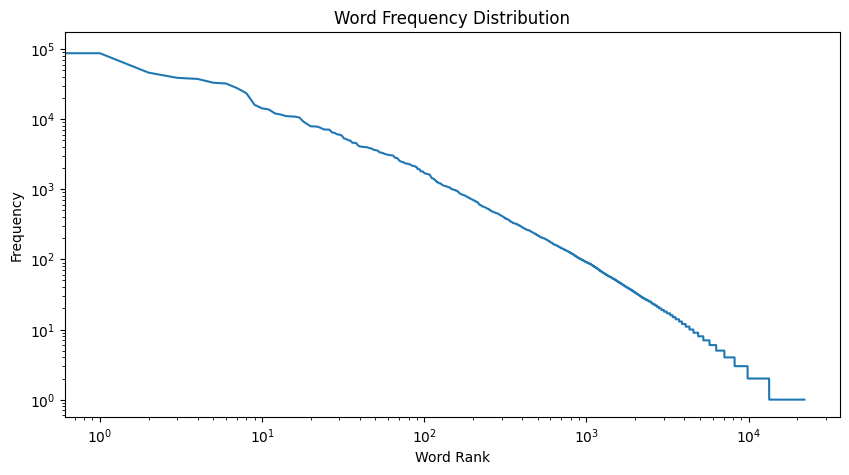

In [18]:
# Zipfs Law to assess frequency distribution for words not token ids
frequencies = sorted(word_counts.values(), reverse=True)
plt.figure(figsize=(10, 5))
plt.plot(frequencies)
plt.yscale("log")
plt.xscale("log")
plt.title("Word Frequency Distribution")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")
plt.show()

The word-frequency distribution exhibits a clear long-tail pattern characteristic of natural language corpora. A relatively small number of highly frequent conversational terms account for a large fraction of the corpus, while many vocabulary items occur infrequently. This behavior is consistent with Zipf's Law and motivates the use of subword tokenization (our gpt tokenizer) to improve the representation of rare terms during training.

##### Summary: Dataset Inspection

The DailyDialog dataset was successfully loaded and inspected to understand its structure, size, and suitability for autoregressive language modeling. The training set contains 11,118 human-authored conversations, with corresponding emotion and dialogue-act annotation files aligned at the conversation level. Each conversation is stored as a single text entry, and individual utterances are separated by the special token `__eou__` (End of Utterance), providing explicit conversational turn boundaries that can be preserved during Transformer training.

Exploratory analysis showed that conversations contain an average of 7.84 utterances, with a maximum of 35 utterances per conversation. Conversations contain an average of 114.5 words, indicating that the dataset provides meaningful conversational context while remaining computationally manageable for a compact Transformer architecture. The dataset consists of approximately 1.27 million words and 22,076 unique vocabulary terms.

Vocabulary analysis revealed a long-tailed distribution characteristic of natural language corpora. Approximately 39.4% of vocabulary terms appear only once, while a small number of highly frequent conversational words account for a large proportion of the dataset. The GPT-2 tokenizer was evaluated as the candidate tokenization strategy and was found to utilize 19,702 unique token identifiers, representing approximately 39.2% of the tokenizer's available vocabulary. This suggests that the GPT-2 tokenizer provides meaningful coverage of the conversational language present in the corpus. However, approximately 60.8% of the GPT-2 vocabulary was not observed within the DailyDialog training corpus. While retaining the full GPT-2 vocabulary simplifies implementation and provides robust subword coverage, future iterations of this project could investigate corpus-specific vocabulary reduction strategies to improve parameter efficiency in the embedding and output projection layers.

The dialogue text data will be our primary datasets used for model training, testing and validation. This data represents the converstional structure required to meet our objective.

### Data Preparation

In [19]:
# Get relevant tokenizer details
print(tokenizer.eos_token)
print(tokenizer.eos_token_id)

<|endoftext|>
50256


In [20]:
# Testing one sample before EOS processing
sample_conversation = dialogues[0].strip() + " " + tokenizer.eos_token

print(sample_conversation[-150:])

ould ask them to go dancing with us.That is excellent exercise and fun , too . __eou__ Good.Let ' s go now . __eou__ All right . __eou__ <|endoftext|>


In [21]:
processed_dialogues = [
    conversation.strip() + " " + tokenizer.eos_token
    for conversation in dialogues
]

print(f"Processed conversations: {len(processed_dialogues):,}")

Processed conversations: 11,118


In [22]:
# process validation and test set

processed_validation = [
    conversation.strip() + " " + tokenizer.eos_token
    for conversation in validation_dialogues
]

processed_test = [
    conversation.strip() + " " + tokenizer.eos_token
    for conversation in test_dialogues
]

In [23]:
# tokenize the dialogues to compute the statistics
tokenized_dialogues = [
    tokenizer.encode(conversation)
    for conversation in processed_dialogues
]

print(f"Tokenized conversations: {len(tokenized_dialogues):,}")

Tokenized conversations: 11,118


In [24]:
token_lengths = [
    len(tokens)
    for tokens in tokenized_dialogues
]

print(f"Average token length: {sum(token_lengths)/len(token_lengths):.2f}")
print(f"Maximum token length: {max(token_lengths)}")
print(f"Minimum token length: {min(token_lengths)}")

print(f"Median: {np.median(token_lengths):.0f}")
print(f"95th Percentile: {np.percentile(token_lengths, 95):.0f}")

Average token length: 146.99
Maximum token length: 952
Minimum token length: 15
Median: 129
95th Percentile: 327


A context length of 256 tokens was selected based on the observed token-length distribution of the DailyDialog corpus. While the median conversation length was approximately 129 tokens, the 95th percentile reached 327 tokens. A 256-token context window provides a balance between conversational coverage and computational efficiency while remaining suitable for training on Google Colab hardware.

In [25]:
# continuous stream approach to creating sliding windows
all_tokens = []

for conversation in processed_dialogues:
    all_tokens.extend(
        tokenizer.encode(conversation)
    )

print(f"Total tokens in corpus: {len(all_tokens):,}")

Total tokens in corpus: 1,634,226


In [26]:
validation_tokens = []

for conversation in processed_validation:
    validation_tokens.extend(
        tokenizer.encode(conversation)
    )

test_tokens = []

for conversation in processed_test:
    test_tokens.extend(
        tokenizer.encode(conversation)
    )

print(
    f"Validation Tokens: {len(validation_tokens):,}"
)

print(
    f"Test Tokens: {len(test_tokens):,}"
)

Validation Tokens: 146,556
Test Tokens: 150,285


In [27]:
print(all_tokens[:20])
print(all_tokens[-20:])

[25515, 837, 5395, 837, 703, 546, 1016, 329, 257, 1178, 16800, 706, 8073, 5633, 11593, 68, 280, 834, 921, 760]
[5633, 11593, 68, 280, 834, 16805, 764, 314, 1183, 655, 307, 257, 5664, 764, 11593, 68, 280, 834, 220, 50256]


In [28]:
print(f"Vocabulary IDs observed: {len(set(all_tokens)):,}")

Vocabulary IDs observed: 19,702


In [29]:
CONTEXT_LENGTH = 256

total_windows = len(all_tokens) - CONTEXT_LENGTH

print(f"Potential training windows: {total_windows:,}")

Potential training windows: 1,633,970


In [30]:
class GPTDialogueDataset(Dataset):

    def __init__( self, token_ids, block_size, stride=16 ):
        self.token_ids = token_ids
        self.block_size = block_size
        self.stride = stride

    def __len__(self):

        return ( len(self.token_ids) - self.block_size ) // self.stride

    def __getitem__(self, idx):

        start = idx * self.stride

        x = torch.tensor(
            self.token_ids[
                start : start + self.block_size
            ],
            dtype=torch.long
        )

        y = torch.tensor(
            self.token_ids[
                start + 1 :
                start + self.block_size + 1
            ],
            dtype=torch.long
        )

        return x, y

In [31]:
STRIDE = 16 # for training effeciency we chose to go with a stride option here
TEST_STRIDE = CONTEXT_LENGTH

train_dataset = GPTDialogueDataset(
    all_tokens,
    block_size=CONTEXT_LENGTH,
    stride=STRIDE
)

print(f"Training samples: {len(train_dataset):,}")

Training samples: 102,123


In [32]:
val_dataset = GPTDialogueDataset(
    validation_tokens,
    block_size=CONTEXT_LENGTH,
    stride=TEST_STRIDE
)

test_dataset = GPTDialogueDataset(
    test_tokens,
    block_size=CONTEXT_LENGTH,
    stride=TEST_STRIDE
)

print(
    f"Validation Samples: {len(val_dataset):,}"
)

print(
    f"Test Samples: {len(test_dataset):,}"
)

Validation Samples: 571
Test Samples: 586


In [33]:
x, y = train_dataset[0]

print("Input Shape:", x.shape)
print("Target Shape:", y.shape)

print("\nShift Verification:")
print(torch.equal(x[1:], y[:-1]))

Input Shape: torch.Size([256])
Target Shape: torch.Size([256])

Shift Verification:
True


In [34]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

In [35]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)
print(batch_y.shape)

torch.Size([16, 256])
torch.Size([16, 256])


In [36]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(
    f"Validation Batches: {len(val_loader):,}"
)

print(
    f"Test Batches: {len(test_loader):,}"
)

Validation Batches: 36
Test Batches: 37


In [37]:
val_x, val_y = next(iter(val_loader))

print("Validation Input Shape :", val_x.shape)
print("Validation Target Shape:", val_y.shape)

Validation Input Shape : torch.Size([16, 256])
Validation Target Shape: torch.Size([16, 256])


##### Dataset Preparation

The DailyDialog conversations were converted into a continuous token stream by preserving the `__eou__` utterance boundary token and appending the GPT-2 end of sequence token to each conversation. A context window length of 256 tokens was selected based on the observed token-length distribution. A custom PyTorch Dataset was implemented to generate sliding training windows on demand, avoiding the need to materialize over 1.6 million windows in memory. The DataLoader is responsible for efficient batching, shuffling, and delivery of training examples to the GPU during model training. A stride of 16 was set for compute efficiency but we can always adjust if training is effected.

##### Validation and Test Data Preparation

The official DailyDialog validation and test partitions were processed using the same tokenization and window-generation pipeline applied to the training set. Continuous token streams were constructed using the GPT-2 tokenizer while preserving conversation boundary information through the `__eou__` and end-of-sequence tokens. Fixed-length training windows were generated using a context length of 256 tokens. For validation and test evaluation, a stride equal to the context length (256 tokens) was used to create non-overlapping evaluation windows, reducing redundancy while providing a representative estimate of model performance on unseen data.

### Implement Baseline Deep Learning Model (Decoder Only Transformer)

In [38]:
# base variables for model
VOCAB_SIZE     = 50_257
CONTEXT_LENGTH = 256

EMBED_DIM      = 128
NUM_HEADS      = 4
NUM_LAYERS     = 2

FF_DIM         = 512   # 4 × embed_dim

DROPOUT        = 0.1

In [39]:
# Check for GPU (CUDA), or fallback to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


In [40]:
# create the token embedding
token_embedding = nn.Embedding(
    num_embeddings=VOCAB_SIZE,
    embedding_dim=EMBED_DIM
)

In [41]:
batch_x, batch_y = next(iter(train_loader))

In [42]:
embedded_tokens = token_embedding(batch_x)

print("Input Shape:", batch_x.shape)
print("Embedding Shape:", embedded_tokens.shape)

Input Shape: torch.Size([16, 256])
Embedding Shape: torch.Size([16, 256, 128])


In [43]:
# position embedding to be added before attention blocks
position_embedding = nn.Embedding(
    num_embeddings=CONTEXT_LENGTH,
    embedding_dim=EMBED_DIM
)

In [44]:
# get the position ids
position_ids = torch.arange(CONTEXT_LENGTH, device=batch_x.device)


In [45]:
position_embeddings = position_embedding(position_ids)

In [46]:
embedded_tokens = token_embedding(batch_x)

position_ids = torch.arange(CONTEXT_LENGTH)

position_embeddings = position_embedding(position_ids)

x = embedded_tokens + position_embeddings

In [47]:
print(embedded_tokens.shape)

print(position_embeddings.shape)
# making sure shapes match up so tensor math computes correctly
print(x.shape)

torch.Size([16, 256, 128])
torch.Size([256, 128])
torch.Size([16, 256, 128])


In [48]:
class CausalSelfAttention(nn.Module):

    def __init__(self, embed_dim, context_length):
        super().__init__()

        self.embed_dim = embed_dim

        self.query = nn.Linear(embed_dim, embed_dim, bias=False)
        self.key   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.value = nn.Linear(embed_dim, embed_dim, bias=False)

        # Register causal mask once
        self.register_buffer( "mask",torch.tril(torch.ones(context_length, context_length)))

    def forward(self, x):

        B, T, C = x.shape

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Attention scores
        attention_scores = (
            Q @ K.transpose(-2, -1)
        ) / math.sqrt(C)

        # Apply causal mask
        attention_scores = attention_scores.masked_fill(
            self.mask[:T, :T] == 0,
            float("-inf")
        )

        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )

        output = attention_weights @ V

        return output

In [49]:
attention = CausalSelfAttention(embed_dim=EMBED_DIM, context_length=CONTEXT_LENGTH)

In [50]:
attention_output = attention(x)
# x being our token+position embedding from earlier which is our production input
print("Attention Input Shape:", x.shape)
print("Attention Output Shape:", attention_output.shape)

Attention Input Shape: torch.Size([16, 256, 128])
Attention Output Shape: torch.Size([16, 256, 128])


##### Embeddings and Single Head Self Attention



Token embeddings transform input token identifiers into dense 128-dimensional vector representations, while positional embeddings provide sequence-order information that would otherwise be unavailable to the Transformer architecture. A causal self-attention mechanism was implemented to allow each token to attend only to previous tokens within the context window. The causal mask prevents future-token leakage during training, ensuring that the model learns a valid autoregressive next-token prediction objective. Shape testing proved successfull and we can now upgrade to a multi head approach.

In [51]:
# Multi Head Attention Verbose for research purposes
class MultiHeadCausalSelfAttention(nn.Module):

    def __init__( self, embed_dim, num_heads, context_length ):
        super().__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        assert (embed_dim % num_heads == 0), "embed_dim must be divisible by num_heads"

        self.query = nn.Linear(embed_dim, embed_dim, bias=False)

        self.key = nn.Linear(embed_dim, embed_dim, bias=False)

        self.value = nn.Linear(embed_dim, embed_dim,bias=False)

        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=False)

        self.register_buffer( "mask", torch.tril( torch.ones( context_length, context_length ) ) )

    def forward(self, x):

        B, T, C = x.shape

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # Split into heads
        q = q.view( B, T, self.num_heads, self.head_dim ).transpose(1, 2)

        k = k.view( B, T, self.num_heads, self.head_dim ).transpose(1, 2)

        v = v.view( B, T, self.num_heads, self.head_dim ).transpose(1, 2)

        # Attention
        attention_scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(self.head_dim)

        attention_scores = attention_scores.masked_fill(
            self.mask[:T, :T] == 0,
            float("-inf")
        )

        attention_weights = F.softmax(
            attention_scores,
            dim=-1
        )

        output = attention_weights @ v

        # Combine heads
        output = ( output .transpose(1, 2) .contiguous() .view(B, T, C) )

        output = self.out_proj(output)

        return output

In [52]:
multi_head_attention = MultiHeadCausalSelfAttention(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    context_length=CONTEXT_LENGTH
)

In [53]:
attention_output = multi_head_attention(x)

print(x.shape)
print(attention_output.shape)

torch.Size([16, 256, 128])
torch.Size([16, 256, 128])


An educational implementation of multi-head causal self-attention was first developed to verify tensor shapes and masking behavior. After confirming correctness, the implementation was refactored to use PyTorch's `scaled_dot_product_attention()` utility, which automatically applies optimized attention kernels such as Flash Attention when supported by the underlying hardware.

In [54]:
# Modern Approach to Multi Head Attention
class MultiHeadCausalSelfAttention(nn.Module):

    def __init__( self, embed_dim, num_heads, dropout=0.1 ):
        super().__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout

        self.head_dim = embed_dim // num_heads

        assert (embed_dim % num_heads == 0 ), "embed_dim must be divisible by num_heads"

        self.query = nn.Linear( embed_dim, embed_dim, bias=False )

        self.key = nn.Linear( embed_dim, embed_dim, bias=False )

        self.value = nn.Linear( embed_dim, embed_dim, bias=False )

        self.out_proj = nn.Linear( embed_dim, embed_dim, bias=False )

    def forward(self, x):

        B, T, C = x.shape

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = q.view( B, T, self.num_heads, self.head_dim ).transpose(1, 2)

        k = k.view( B, T, self.num_heads, self.head_dim ).transpose(1, 2)

        v = v.view( B, T, self.num_heads, self.head_dim ).transpose(1, 2)

        output = F.scaled_dot_product_attention(
            query=q,
            key=k,
            value=v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True
        )

        output = (
            output
            .transpose(1, 2)
            .contiguous()
            .view(B, T, C)
        )

        return self.out_proj(output)

In [55]:
flash_attention = MultiHeadCausalSelfAttention(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS
)

attention_output = flash_attention(x)

# Shape verification
print(x.shape)
print(attention_output.shape)

torch.Size([16, 256, 128])
torch.Size([16, 256, 128])


A manual implementation of multi-head causal self-attention was first developed to verify tensor operations, masking behavior, and shape transformations. The implementation was subsequently refactored to leverage PyTorch's optimized scaled dot-product attention routine, enabling modern attention kernels such as Flash Attention when supported by the execution environment.

##### Feed Forward Block

In [56]:
class FeedForward(nn.Module):

    def __init__( self, embed_dim, ff_dim, dropout=0.1 ):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear( embed_dim, ff_dim ),

            nn.GELU(),

            nn.Linear( ff_dim, embed_dim ),

            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [57]:
ffn = FeedForward(
    embed_dim=EMBED_DIM,
    ff_dim=FF_DIM
)

In [58]:
ff_output = ffn(x)
# shape verification
print(x.shape)
print(ff_output.shape)

torch.Size([16, 256, 128])
torch.Size([16, 256, 128])


The Feed Forward Network (FFN) processes each token representation independently after the attention mechanism has incorporated contextual information. Following common GPT design practices, the network expands the embedding dimension from 128 to 512 dimensions using a linear layer and GELU activation before projecting back to the original embedding dimension. This component increases the model's representational capacity while preserving the input shape required for residual connections.

##### Transformer Block
**Pre-Layer Norm**

In [59]:
class TransformerBlock(nn.Module):

    def __init__( self, embed_dim, num_heads, ff_dim, dropout=0.1 ):
        super().__init__()

        self.ln1 = nn.LayerNorm(embed_dim)

        self.attention = MultiHeadCausalSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        self.ln2 = nn.LayerNorm(embed_dim)

        self.ffn = FeedForward(
            embed_dim=embed_dim,
            ff_dim=ff_dim,
            dropout=dropout
        )

    def forward(self, x):

        # Pre-LN Attention
        # simple skip connection here
        x = x + self.attention(
            self.ln1(x)
        )

        # Pre-LN FFN
        x = x + self.ffn(
            self.ln2(x)
        )

        return x

In [60]:
# verify shape once again
transformer_block = TransformerBlock(
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM
)

In [61]:
block_output = transformer_block(x)

print("Input Shape :", x.shape)
print("Output Shape:", block_output.shape)

Input Shape : torch.Size([16, 256, 128])
Output Shape: torch.Size([16, 256, 128])


The Transformer block combines multi-head causal self-attention and a position wise feed-forward network (no leakages and sequential) using a modern Pre-LayerNorm architecture. Residual connections are applied around both sublayers, allowing information and gradients to flow directly through the network while enabling each component to learn useful refinements to the token representations. This block serves as the fundamental building unit of the decoder-only Transformer model.

In [62]:
# small GPT
class GPTModel(nn.Module):

    def __init__( self, vocab_size, context_length, embed_dim, num_heads, num_layers, ff_dim, dropout=0.1 ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, embed_dim)

        self.position_embedding = nn.Embedding(context_length, embed_dim)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

        self.final_ln = nn.LayerNorm(
            embed_dim
        )

        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)

    def forward(self, x):

        B, T = x.shape

        positions = torch.arange(
            T,
            device=x.device
        )

        token_embeddings = self.token_embedding(x)

        position_embeddings = self.position_embedding(
            positions
        )

        x = token_embeddings + position_embeddings

        for block in self.blocks:
            x = block(x)

        x = self.final_ln(x)

        logits = self.lm_head(x)

        return logits

In [63]:
model = GPTModel(
    vocab_size=VOCAB_SIZE,
    context_length=CONTEXT_LENGTH,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM
)

In [64]:
# Define target device based on what Colab has allocated
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# MOVE the model to the T4 GPU
model.to(device)

# VERIFY the move worked using your snippet
current_device = next(model.parameters()).device
print(f"The model is actively running on: {current_device}")

The model is actively running on: cuda:0


In [65]:
batch_x, batch_y = next(
    iter(train_loader)
)

batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

logits = model(batch_x)

print("Input Shape :", batch_x.shape)
print("Logits Shape:", logits.shape)

Input Shape : torch.Size([16, 256])
Logits Shape: torch.Size([16, 256, 50257])


The baseline model follows a GPT-style decoder-only Transformer architecture designed for autoregressive next-token prediction. Input token identifiers are converted into dense vector representations using token and positional embeddings before passing through a stack of Transformer blocks. Each block consists of Pre-LayerNorm multi-head causal self-attention, a position-wise feed-forward network, and residual connections that enable stable gradient flow.

The model uses a context window of 256 tokens, an embedding dimension of 128, four attention heads, and two Transformer blocks. A final LayerNorm and vocabulary projection layer produce token logits for every position in the sequence, allowing the model to predict the most likely next token during training and generation.

##### Model Training

In [66]:
# Figure out total parameters for the model to be trained on single gpu
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 13,294,336
Trainable Parameters: 13,294,336


In [67]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.01
)

### Loss Function and Optimizer

The model is trained using categorical cross-entropy loss, which is the standard objective for autoregressive language modeling and measures how accurately the model predicts the next token in a sequence. The AdamW optimizer is used for parameter updates because it combines adaptive gradient-based optimization with decoupled weight decay, making it well suited to Transformer architectures. During training, token-level predictions are flattened across the batch and sequence dimensions to match the input requirements of the cross-entropy loss function.

In [68]:
print(f"Using device: {device}")

Using device: cuda


In [69]:
model.train()

batch_x, batch_y = next(
    iter(train_loader)
)

batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

logits = model(batch_x)

print("Logits Shape:", logits.shape)
print("Targets Shape:", batch_y.shape)

Logits Shape: torch.Size([16, 256, 50257])
Targets Shape: torch.Size([16, 256])


In [70]:
# we have to adapt and reshape for cross entropy loss to matrix size
logits = logits.view(
    -1,
    VOCAB_SIZE
)

targets = batch_y.view(-1)

print("Flattened Logits:", logits.shape)
print("Flattened Targets:", targets.shape)

Flattened Logits: torch.Size([4096, 50257])
Flattened Targets: torch.Size([4096])


In [71]:
# test loss
loss = loss_fn(
    logits,
    targets
)

print(
    f"Initial Loss: {loss.item():.4f}"
)

Initial Loss: 10.9339


In [72]:
# backpropagation test
optimizer.zero_grad()

loss.backward()

optimizer.step()

print(
    "Single training step completed."
)

Single training step completed.


Before implementing the full training procedure, a single optimization step was performed to verify correct integration between the dataset, model, loss function, and optimizer. The model outputs were reshaped to match the input requirements of the cross-entropy loss function, allowing next-token predictions from all positions in the batch to be evaluated simultaneously. Successful completion of a forward and backward pass confirmed that gradients propagate correctly throughout the entire architecture.

In [73]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=50, device="cpu"):
    model.eval()

    tokens = tokenizer.encode(prompt)
    tokens = torch.tensor(
        tokens,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    for _ in range(max_new_tokens):

        tokens_cond = tokens[:, -CONTEXT_LENGTH:]

        logits = model(tokens_cond)
        # Extract last token
        logits = logits[:, -1, :]

        probs = torch.softmax(
            logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        tokens = torch.cat(
            [tokens, next_token],
            dim=1
        )

    return tokenizer.decode(
        tokens[0].tolist()
    )

In [74]:
print(
    generate(
        model,
        tokenizer,
        prompt="Hello",
        max_new_tokens=50,
        device=device
    )
)
# always love the inital generations

Helloadjustedantis concess Astonult hobbies fossils POLIT Apprentice Potion Source elf Points ls qualitativeicked Uz spawns droveLine Crate recognizes514ucer dreadubs marocr saints polic Oriental2015 datingearance� Por GB 1850ORNi canned401)", lizard Syrianbc regex;;;;;;;;;;;;DonaldTrump foregoing


**Baseline Generation complete, nice to see some room for improvment there**

##### Training Loop

In [75]:
train_losses = []
val_losses = []


def train_epoch(model, dataloader, optimizer, loss_fn, device):

    model.train()

    running_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for batch_x, batch_y in progress_bar:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)

        logits = logits.view(
            -1,
            VOCAB_SIZE
        )

        targets = batch_y.view(-1)

        loss = loss_fn(
            logits,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (running_loss / len(dataloader))

    return epoch_loss

In [76]:
# Single Epoch test before training loop for verification

# epoch_loss = train_epoch(
#     model,
#     train_loader,
#     optimizer,
#     loss_fn,
#     device
# )

# print( f"Epoch Loss: {epoch_loss:.4f}" )

In [77]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device):
    model.eval()

    running_loss = 0.0

    for batch_x, batch_y in dataloader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)

        logits = logits.view(
            -1,
            VOCAB_SIZE
        )

        targets = batch_y.view(-1)

        loss = loss_fn(
            logits,
            targets
        )

        running_loss += loss.item()

    return running_loss / len(dataloader)

In [78]:
train_losses = []
val_losses = []

EPOCHS = 3

best_val_loss = float("inf")

print(f"Starting training on device: {device}\n" + "=" * 40)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 20)

    # Training
    train_loss = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device
    )

    # Validation
    val_loss = evaluate(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=device
    )

    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "../checkpoints/base_gpt_model.pt"
        )

        print("Best model checkpoint saved.")

    # Epoch summary
    print(
        f"\nSummary -> "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

    # Qualitative generation checkpoint
    print("\n[Sampling Checkpoint]")

    sample_output = generate(
        model=model,
        tokenizer=tokenizer,
        prompt="Hello, how are you today? __eou__",
        max_new_tokens=30,
        device=device
    )

    print(
        f"Prompt: 'Hello, how are you today? __eou__'\n"
        f"Generated: {sample_output}"
    )

    print("=" * 40)

print("\nTraining complete.")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Starting training on device: cuda

Epoch 1/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 3.6873 | Validation Loss: 3.4251

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ This is terrible . __eou__ Do you think ir , that is almostlim record it doesn't bad idea . ? __eou__ I

Epoch 2/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 3.0307 | Validation Loss: 3.2543

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ Mr . I have got it that you lived here . __eou__ Oh , then last Friday Hotel . Nice to meet you please . Welcome to

Epoch 3/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 2.7638 | Validation Loss: 3.1903

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ Time Depos by me which do you normally often like . __eou__ Is it going on ? __eou__ Well , the sixth floor

Training complete.
Best Validation Loss: 3.1903


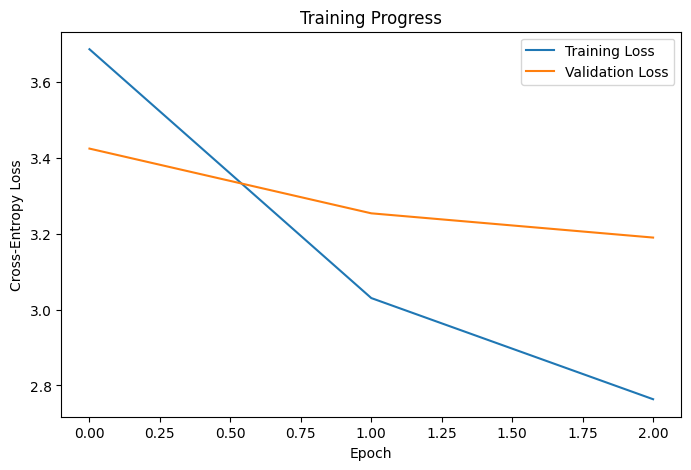

In [79]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Progress")

plt.legend()

plt.show()

In [80]:
test_loss = evaluate(
    model=model,
    dataloader=test_loader,
    loss_fn=loss_fn,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")

Test Loss: 3.1156


Training and validation losses decreased consistently across all epochs, indicating successful optimization of the decoder-only Transformer. Validation loss initially appeared slightly lower than training loss, which may be partially explained by the use of dropout during training and the differing sampling strategies used for training and evaluation datasets. The final test loss of 3.12 closely matched the validation loss of 3.19, suggesting good generalization performance and little evidence of overfitting.

### Experiment 1 (search for model improvement)
##### Layer (depth) 2 > 4

In [81]:
NUM_LAYERS = 4

model1 = GPTModel(
    vocab_size=VOCAB_SIZE,
    context_length=CONTEXT_LENGTH,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM
)

model1 = model1.to(device)

total_params = sum(
    p.numel()
    for p in model1.parameters()
)

print(f"Total Parameters: {total_params:,}")

Total Parameters: 13,689,856


In [82]:
n_optimizer = torch.optim.AdamW(
    model1.parameters(),
    lr=3e-4,
    weight_decay=0.01
)

In [83]:
train_losses = []
val_losses = []

EPOCHS = 3

best_val_loss = float("inf")

print(f"Starting training on device: {device}\n" + "=" * 40)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 20)

    # Training
    train_loss = train_epoch(
        model=model1,
        dataloader=train_loader,
        optimizer=n_optimizer,
        loss_fn=loss_fn,
        device=device
    )

    # Validation
    val_loss = evaluate(
        model=model1,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=device
    )

    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model1.state_dict(),
            "../checkpoints/depth_gpt_model.pt"
        )

        print("Best model checkpoint saved.")

    # Epoch summary
    print(
        f"\nSummary -> "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

    # Qualitative generation checkpoint
    print("\n[Sampling Checkpoint]")

    sample_output = generate(
        model=model1,
        tokenizer=tokenizer,
        prompt="Hello, how are you today? __eou__",
        max_new_tokens=30,
        device=device
    )

    print(
        f"Prompt: 'Hello, how are you today? __eou__'\n"
        f"Generated: {sample_output}"
    )

    print("=" * 40)

print("\nTraining complete.")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Starting training on device: cuda

Epoch 1/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 3.5817 | Validation Loss: 3.2773

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ Oh , let , then ... oh , who they are connected it ! __eou__ Can I see you ? __eou__ I decide if

Epoch 2/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 2.8499 | Validation Loss: 3.0923

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ well , of course . I am sure my application was a trademark . __eou__ What a pity ! __eou__ <|endoftext|>why read

Epoch 3/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 2.5529 | Validation Loss: 3.0442

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ Very well . I would like to have a dozen of in the tourism area , preferably in short term . You can't resist too soon as possible .

Training complete.
Best Validation Loss: 3.0442


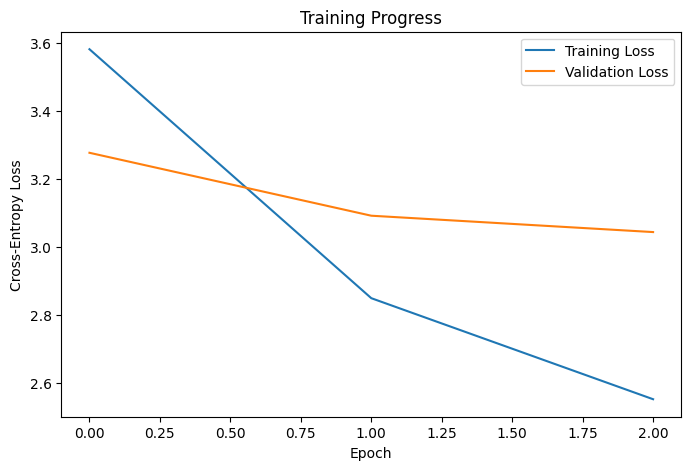

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Progress")

plt.legend()

plt.show()

In [85]:
test_loss = evaluate(
    model=model1,
    dataloader=test_loader,
    loss_fn=loss_fn,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")

Test Loss: 2.9701


##### Experiment 2
##### Embedding Change

In [86]:
NUM_LAYERS = 2 # for a scientific experiment integrity we reset layers to 2 to preserve the control model
EMBED_DIM = 256
FF_DIM = 1024 # embedding * 4 preserved

In [87]:
NUM_LAYERS = 2

EMBED_DIM = 256
FF_DIM = 1024

model2 = GPTModel(
    vocab_size=VOCAB_SIZE,
    context_length=CONTEXT_LENGTH,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,      # still 4
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM
)

model2 = model2.to(device)

In [88]:
total_params = sum(
    p.numel()
    for p in model2.parameters()
)

print(
    f"Total Parameters: {total_params:,}"
)

Total Parameters: 27,375,104


In [89]:
e_optimizer = torch.optim.AdamW(
    model2.parameters(),
    lr=3e-4,
    weight_decay=0.01
)

In [90]:
batch_x, batch_y = next(iter(train_loader))

batch_x = batch_x.to(device)

logits = model2(batch_x)

print(logits.shape)

torch.Size([16, 256, 50257])


In [91]:
train_losses = []
val_losses = []

EPOCHS = 3

best_val_loss = float("inf")

print(f"Starting training on device: {device}\n" + "=" * 40)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 20)

    # Training
    train_loss = train_epoch(
        model=model2,
        dataloader=train_loader,
        optimizer=e_optimizer,
        loss_fn=loss_fn,
        device=device
    )

    # Validation
    val_loss = evaluate(
        model=model2,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=device
    )

    # Track metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model2.state_dict(),
            "../checkpoints/width_gpt_model.pt"
        )

        print("Best model checkpoint saved.")

    # Epoch summary
    print(
        f"\nSummary -> "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

    # Qualitative generation checkpoint
    print("\n[Sampling Checkpoint]")

    sample_output = generate(
        model=model2,
        tokenizer=tokenizer,
        prompt="Hello, how are you today? __eou__",
        max_new_tokens=30,
        device=device
    )

    print(
        f"Prompt: 'Hello, how are you today? __eou__'\n"
        f"Generated: {sample_output}"
    )

    print("=" * 40)

print("\nTraining complete.")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Starting training on device: cuda

Epoch 1/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 3.3213 | Validation Loss: 3.1545

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ Mr . Zhang Frank Crane , who is she strict ? __eou__ It is quite slender sophisticated . I have no regrets at this morning and I

Epoch 2/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]

Best model checkpoint saved.

Summary -> Train Loss: 2.5284 | Validation Loss: 3.0665

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ <|endoftext|>Excuse me , miss ? But can I help you ? __eou__ Yes , I would really like to be going to go to

Epoch 3/3
--------------------


Training:   0%|          | 0/6382 [00:00<?, ?it/s]


Summary -> Train Loss: 2.1817 | Validation Loss: 3.0981

[Sampling Checkpoint]
Prompt: 'Hello, how are you today? __eou__'
Generated: Hello, how are you today? __eou__ Fine , sir . Can I have your name here ? __eou__ Just a second . __eou__ Come over there , please . Where

Training complete.
Best Validation Loss: 3.0665


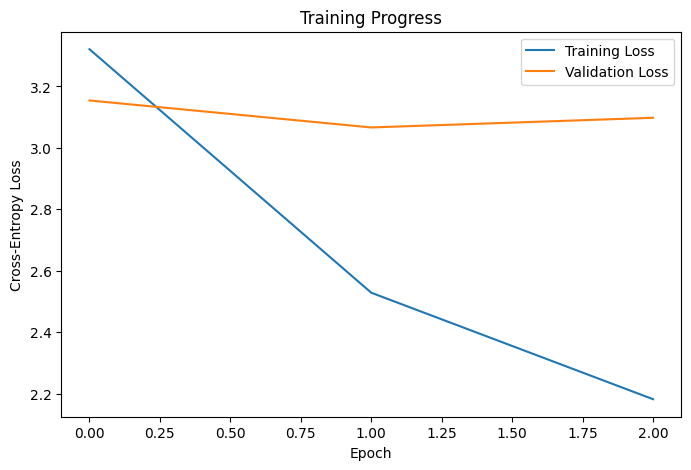

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Progress")

plt.legend()

plt.show()

In [94]:
test_loss = evaluate(
    model=model2,
    dataloader=test_loader,
    loss_fn=loss_fn,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")

Test Loss: 3.0356


### Evaluation and Discussion



| Model Configuration | Layers | Embedding Dimension | Parameters | Train Loss | Validation Loss | Test Loss |
| ------------------- | -----: | ------------------: | ---------: | ---------: | --------------: | --------: |
| Baseline            |      2 |                 128 |     13.30M |     2.7638 |          3.1903 |    3.1156 |
| Depth Experiment    |      4 |                 128 |     13.69M |     2.5529 |          3.0442 |    2.9701 |
| Width Experiment    |      2 |                 256 |     27.38M |     2.1817 |          3.0665 |    3.0356 |


##### Experimental Results

Three decoder-only Transformer configurations were evaluated on the DailyDialog corpus. The baseline model was compared against two controlled architectural modifications: an increase in Transformer depth and an increase in embedding dimensionality. All experiments used the same dataset preprocessing pipeline, context length, optimizer, batch size, learning rate, dropout rate, and training duration. This ensured that observed performance differences could be attributed primarily to the architectural change under investigation.


##### Training Behaviour

All models exhibited stable convergence during training. Training and validation losses decreased throughout the three training epochs, demonstrating that the decoder-only Transformer successfully learned conversational patterns from the DailyDialog corpus.

The baseline model achieved a validation loss of 3.1903 and a test loss of 3.1156. Both experimental configurations improved upon the baseline.

The depth experiment reduced validation loss to 3.0442 and achieved the lowest test loss of 2.9701. The width experiment achieved the lowest training loss of 2.1817 and reduced the test loss to 3.0356.

The loss curves showed consistent downward trends without evidence of unstable optimization or catastrophic overfitting.

##### Generalization

The held-out test set provides the strongest measure of model generalization.

Both experimental configurations improved upon the baseline; however, the depth experiment achieved the strongest performance on the unseen test set.

The close relationship between validation and test losses indicates that the validation partition provided a reliable estimate of generalization performance throughout training.

##### Parameter Efficiency Analysis

A key outcome of the experiments is the difference in parameter efficiency.

**Depth Modification**
Parameters:
13.30M -> 13.69M (+0.39M)

Test Loss:
3.1100 -> 2.9701

**Width Modification**
Parameters:
13.30M -> 27.38M (+14.08M)

Test Loss:
3.1100 -> 3.0356

Although the width experiment used more than twice the number of parameters, it did not outperform the deeper model. This suggests that increasing depth was a more parameter-efficient strategy for improving conversational language modeling performance on the DailyDialog dataset.

##### General Observations
All models learned important conversational structures from the dataset:

- Turn boundaries represented by the __eou__ token.
- Conversation termination represented by the <|endoftext|> token.
- Common dialogue patterns including greetings, questions, and responses.

The baseline model frequently generated grammatically plausible but semantically inconsistent text. Both experimental models produced more coherent conversational openings and more natural turn-taking behaviour.

The depth experiment generally generated the most consistent responses, while the width experiment produced fluent dialogue openings but occasionally exhibited weaker semantic consistency despite its larger parameter count.

### Project Summary

This project implemented a GPT-style decoder-only Transformer from first principles and trained it on the DailyDialog conversational dataset. A baseline model consisting of two Transformer blocks, 128-dimensional embeddings, and approximately 13.3 million parameters was developed and evaluated using training, validation, and test splits. Two controlled architectural experiments were conducted: increasing Transformer depth from two to four layers and increasing embedding dimensionality from 128 to 256 dimensions while keeping all other training conditions constant.

Both experimental configurations improved performance relative to the baseline model. The depth experiment achieved the strongest overall generalization performance, reducing test loss from 3.1100 to 2.9701 while increasing the parameter count by less than 3%. The width experiment achieved the lowest training loss but required over twice as many parameters and produced a smaller improvement in validation and test performance. An interesting outcome of the study was that increasing model depth provided a more parameter-efficient improvement strategy than increasing model width, highlighting the importance of architectural design choices in Transformer-based language models.

Future work would involve consolidating the findings of these experiments to develop a final architecture that balances performance, parameter efficiency, and computational cost. Additional experiments involving context length, attention configurations, and training strategies could further refine the model and identify an optimal configuration for conversational language modeling.